# Statistical Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from matplotlib import pyplot as plt
# import matplotlib.gridspec as gridspec
from glob import glob

In [136]:
data_sources=['landsat', 'modis', 'era5']
countries=['gambia', 'mozambique', 'kenya']
assign_levels=['neighborhood', 'centroid', 'facility', 'district']

hot_gm=['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']# gambia hot season
cold_gm=['Jul', 'Aug', 'Sep', 'Oct']# gambia cold season
hot_mz=['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']# mozambique hot season
cold_mz=['Apr', 'May', 'Jun', 'Jul', 'Aug']# mozambique cold season
hot_ke=['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']# kenya hot season
cold_ke=['May', 'Jun', 'Jul', 'Aug', 'Sep']# kenya cold season

season_markers=dict(gambia=['Jan', 'Jun', 'Nov', 'Dec'], mozambique=['Jan', 'Mar', 'Sep', 'Dec'], kenya=['Jan', 'Apr', 'Oct', 'Dec'])

In [3]:
def assign_season(df):
    if df['country']=='gambia':
        return 'hot' if df['month'] in hot_gm else 'cold'
    elif df['country']=='mozambique': 
        return 'hot' if df['month'] in hot_mz else 'cold'
    elif df['country']=='kenya': 
        return 'hot' if df['month'] in hot_ke else 'cold'

In [4]:
exposures_df=(pd.concat([pd.read_csv(f) for f in glob(os.path.join('outputs', '*combined.csv'))])
              .dropna())
# enable sorting by ordered month names
exposures_df['month']=pd.Categorical(pd.to_datetime(exposures_df['exposure_month'], format='%Y_%m').dt.strftime('%b'),
                                     categories=map(lambda x: x.strftime('%b'), pd.date_range(1, periods=12, freq='M')), ordered=True)
exposures_df['season']=exposures_df.apply(assign_season, axis=1)
exposures_df=exposures_df.sort_values(by='month')
# exposures_df

## Plot the annual trend

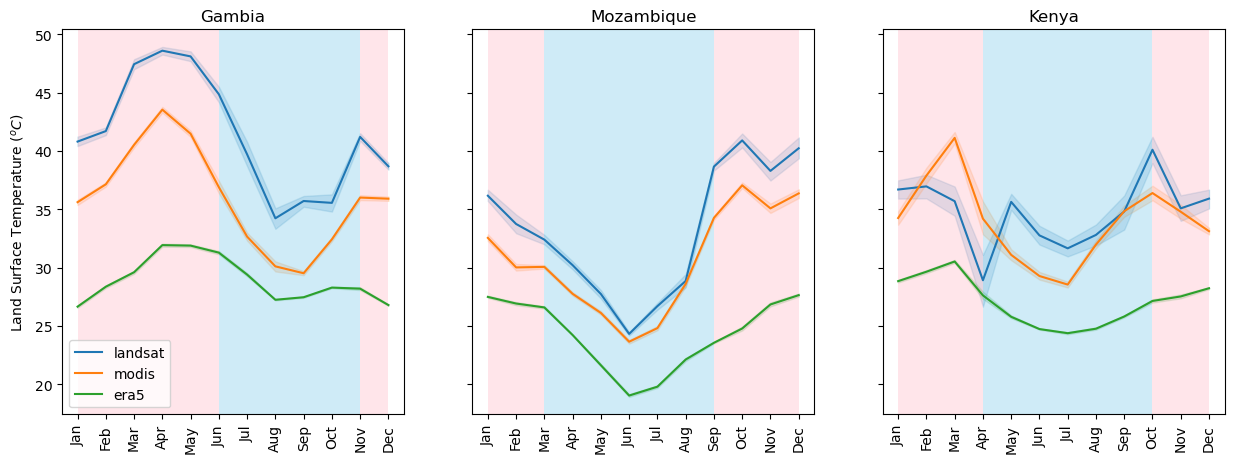

In [139]:
fig, axs=plt.subplots(1, 3, sharey=True, figsize=(15, 5))

for ax, country in zip(axs.flatten(), countries):
    for source in data_sources:
        sns.lineplot(exposures_df[(exposures_df['assign_level']=='centroid')&(exposures_df['country']==country)], x='month', y=source, ax=ax, label=source)
        
    ax.axvspan(*season_markers[country][:2], color='pink', alpha=0.4, linewidth=0)
    ax.axvspan(*season_markers[country][1:3], color='skyblue', alpha=0.4, linewidth=0)
    ax.axvspan(*season_markers[country][2:], color='pink', alpha=0.4, linewidth=0)
    ax.set_title(country.capitalize())
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=90) 
    ax.legend().set_visible(False)
axs[0].set_ylabel('Land Surface Temperature $(^oC)$')
axs[0].legend(ncol=1).set_visible(True)

## Is there correlation among the 3 datasets at different assignment levels?

In [6]:
def compute(df, x, y, level):
    """
    Function to compute Pearson correlation and 95% confidence interval.
    Objective is to determine correlation at different measurement scales (i.e., neighborhood polygon, neighborhood centroid, health facility , district level)
    """
    res=stats.pearsonr(df[x], df[y])
    low, high=res.confidence_interval(confidence_level=0.95)#, method=stats.BootstrapMethod())
    return level, res.statistic, low, high

### Country and season comparisons

In [7]:
def compare_by_country(exposures: pd.DataFrame):
    
    # dataframes for correlation coeffs by dataset
    dffs=dict()
    for source in ['landsat_modis', 'landsat_era5', 'modis_era5']:
        dffs[source]=pd.DataFrame(columns=['level', 'coefficient', 'lower', 'upper'])
    
    for name in dffs.keys():      
        a, b=name.split('_')  
        
        # combined country villages
        dffs[name].loc[0]=compute(exposures, a, b, 'all neighborhoods combined')
      
        # stratified by country
        dffs[name].loc[1]=compute(exposures[exposures['country']=='gambia'], a, b, 'gambia all neighborhoods')
        dffs[name].loc[2]=compute(exposures[exposures['country']=='mozambique'], a, b, 'mozambique all neighborhoods')
        dffs[name].loc[3]=compute(exposures[exposures['country']=='kenya'], a, b, 'kenya all neighborhoods')
            
        # stratified by country seasons
        dffs[name].loc[4]=compute(exposures[(exposures['country']=='gambia') & (exposures['season']=='hot')], a, b, 'gambia hot season')
        dffs[name].loc[5]=compute(exposures[(exposures['country']=='gambia') & (exposures['season']=='cold')], a, b, 'gambia cold season')
        dffs[name].loc[6]=compute(exposures[(exposures['country']=='mozambique') & (exposures['season']=='hot')], a, b, 'mozambique hot season')
        dffs[name].loc[7]=compute(exposures[(exposures['country']=='mozambique') & (exposures['season']=='cold')], a, b, 'mozambique cold season')
        dffs[name].loc[8]=compute(exposures[(exposures['country']=='kenya') & (exposures['season']=='hot')], a, b, 'kenya hot season')
        dffs[name].loc[9]=compute(exposures[(exposures['country']=='kenya') & (exposures['season']=='cold')], a, b, 'kenya cold season')
    
        # prepare plotting filter columns
        '''
        ToDo
        check to see if filtering before corr gives same results as filtering after
        '''
        dffs[name]['country']=dffs[name]['level'].map(lambda x: x.split(' ')[0])
        dffs[name]['season']=dffs[name]['level'].map(lambda x: x.split(' ')[1] if x.endswith('season') else 'all')
        
    return dffs

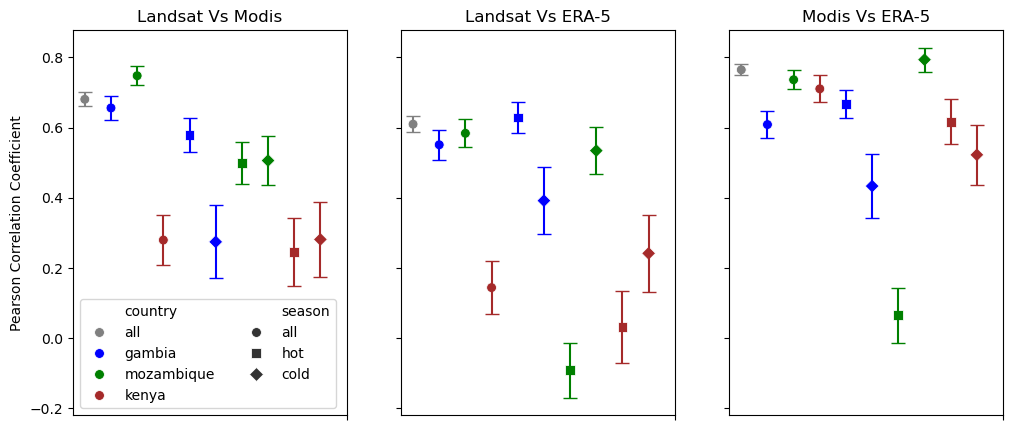

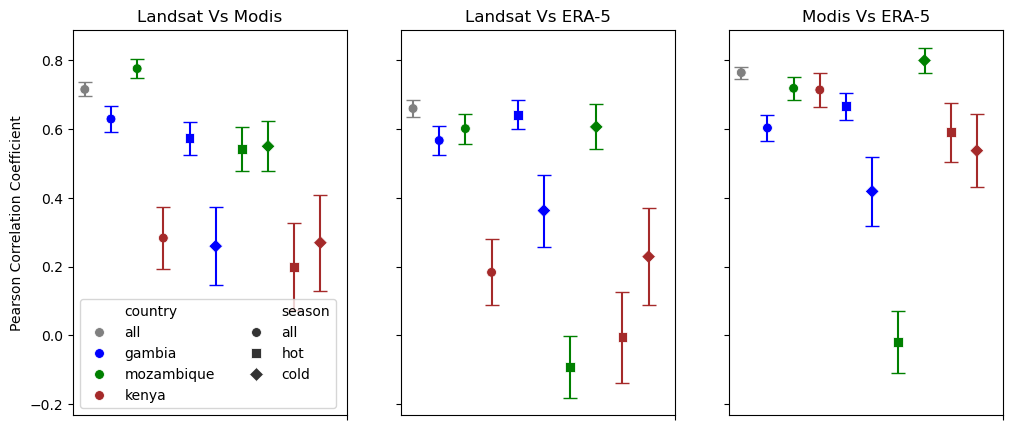

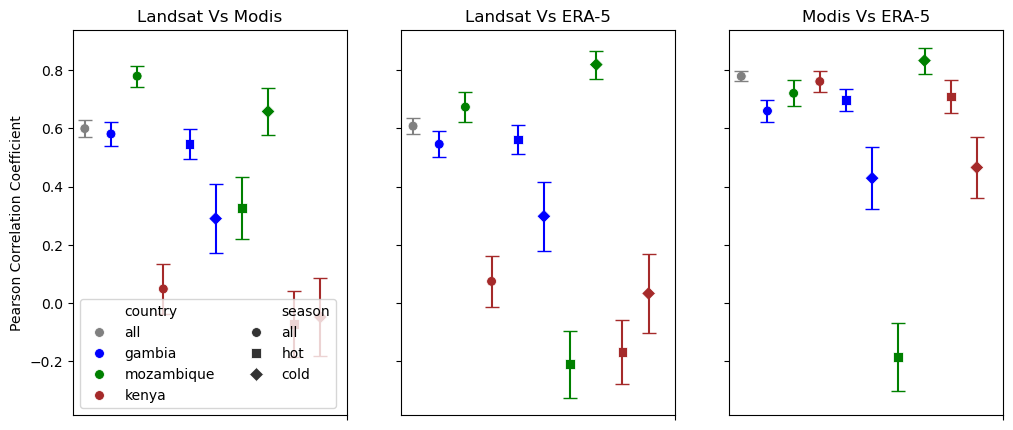

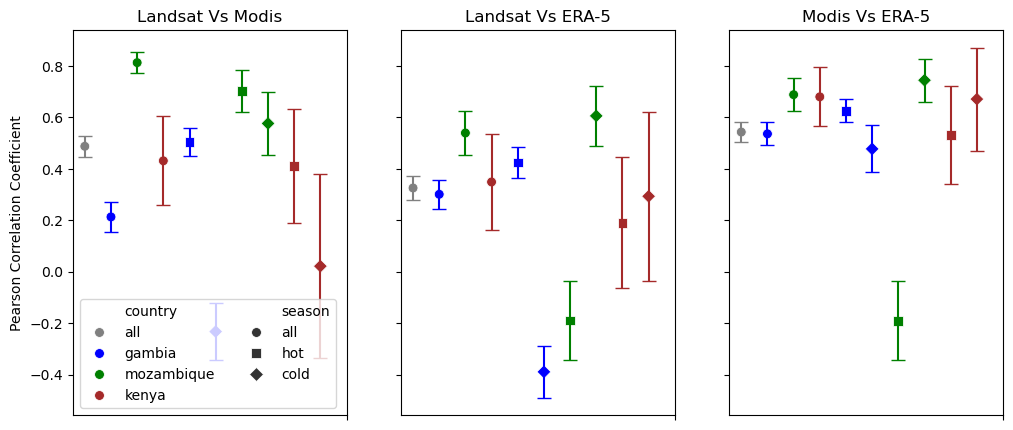

In [8]:
#level='district'
for level in assign_levels:

    # filter df to assignment level
    exposures=exposures_df[exposures_df['assign_level']==level]
    dffs=compare_by_country(exposures)

    fig, axs=plt.subplots(1, 3, sharey=True, sharex=True, figsize=(12, 5))

    for idx, (df, title) in enumerate(zip(dffs.values(), ['Landsat Vs Modis', 'Landsat Vs ERA-5', 'Modis Vs ERA-5'])):

        # create subplots
        sns.scatterplot(df, x='level', y='coefficient', s=50, hue='country', style='season', palette=['grey', 'blue', 'green', 'brown'], markers=['o', 's', 'D'], ax=axs[idx])
        # subset data for errorbar color formatting
        for group, color in zip(df['country'].unique(), ['grey', 'blue', 'green', 'brown']):
            subset=df[df['country']==group]
            axs[idx].errorbar(subset['level'], subset['coefficient'], yerr=subset['upper']-subset['lower'], fmt='none', capsize=5, ecolor=color)

        axs[idx].set_title(title)

    for ax in axs.flatten():
        ax.set_xticks('')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.legend().set_visible(False)
    axs[0].set_ylabel('Pearson Correlation Coefficient')
    axs[0].legend(ncol=2).set_visible(True)

    plt.savefig(os.path.join('outputs/figures_maps', f'{level}_correlation_plots.png'))

### Month-on-month comparison

In [ ]:
df_lm=pd.DataFrame(columns=['level', 'coefficient', 'lower', 'upper']) # landsat_modis
df_le=pd.DataFrame(columns=['level', 'coefficient', 'lower', 'upper']) # landsat_era5
df_me=pd.DataFrame(columns=['level', 'coefficient', 'lower', 'upper']) # modis_era5
count=0
for country in countries:
    exposures_filtered=exposures_df[(exposures_df['assign_level']=='centroid')&(exposures_df['country']==country)]
    
    for month in exposures_filtered['month'].unique():
        exposures=exposures_filtered[exposures_filtered['month']==month]        
        # stratified by country
        df_lm.loc[count, ['level', 'coefficient', 'lower', 'upper']]=compute(exposures, 'landsat', 'modis', f'{country} all neighborhoods')
        df_lm.loc[count, 'month']=month
        df_le.loc[count, ['level', 'coefficient', 'lower', 'upper']]=compute(exposures, 'landsat', 'era5', f'{country} all neighborhoods')
        df_le.loc[count, 'month']=month
        df_me.loc[count, ['level', 'coefficient', 'lower', 'upper']]=compute(exposures, 'modis', 'era5', f'{country} all neighborhoods')
        df_me.loc[count, 'month']=month
        count+=1

In [ ]:
for df in [df_lm, df_le, df_me]:
    df['country']=df['level'].map(lambda x: x.split(' ')[0])
    df['season']=df.apply(assign_season, axis=1)
        
fig, axs=plt.subplots(3, 1, sharey=True, sharex=True, figsize=(10, 12))

for idx, (df, title) in enumerate(zip([df_lm, df_le, df_me], ['Landsat Vs Modis', 'Landsat Vs ERA-5', 'Modis Vs ERA-5'])):
    # subset data for errorbar formatting
    gm=df[df['country']=='gambia']
    mz=df[df['country']=='mozambique']
    ke=df[df['country']=='kenya']
    # create subplots
    sns.scatterplot(df, x='month', y='coefficient', s=50, hue='country', palette=['blue', 'green', 'brown'], style='season', markers=['s', 'D'], ax=axs[idx])
    # axs[idx].errorbar(gm['month'], gm['coefficient'], yerr=gm['upper']-gm['lower'], fmt='none', capsize=5, ecolor='blue')
    # axs[idx].errorbar(mz['month'], mz['coefficient'], yerr=mz['upper']-mz['lower'], fmt='none', capsize=5, ecolor='green')
    
    sns.lineplot(df, x='month', y='coefficient', hue='country', palette=['blue', 'green', 'brown'], ax=axs[idx], legend=False)
    axs[idx].set_title(title)

for ax in axs.flatten():
    # ax.set_xticks('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend().set_visible(False)
# axs[0].set_ylabel('Pearson Correlation Coefficient')
axs[0].legend(ncol=2).set_visible(True)

plt.savefig(os.path.join('outputs/figures_maps', 'monthly_correlation_plots.png'))

### Deciles comparison

In [ ]:
# deciles=pd.DataFrame()
# for code in exposures_df[exposures_df['assign_level']=='village']['neighborhood_code'].unique():
#     exposures=(exposures_df[exposures_df['neighborhood_code']==code].groupby(by='month')[data_sources]
#                .mean()
#                .reset_index())
#     exposures['neighborhood_code']=code
#     exposures['country']=exposures.apply(lambda x: 'mozambique' if str(x['neighborhood_code']).startswith('258') else 'gambia', axis=1)
#     deciles=pd.concat([deciles, exposures])
# deciles.to_csv(os.path.join('outputs', 'monthly_means_v.csv'), index=False)

In [ ]:
means=pd.read_csv(os.path.join('outputs', 'monthly_means_v.csv'))
deciles=pd.DataFrame()
for country in countries:
    for source in data_sources:
        for month in means.month.unique():
            means_=means.copy()
            means_[f'{source}_rank']=pd.qcut(means_[(means_['country']==country) & (means_['month']==month)][source], 100, duplicates='drop', labels=False)
            
            deciles=pd.concat([deciles, means_[(means_['country']==country) & (means_['month']==month)]])
deciles=deciles.groupby(by=['neighborhood_code', 'month']).agg({'country':'max', 'landsat_rank':'max', 'modis_rank':'max', 'era5_rank':'max'})
deciles

In [ ]:
deciles[deciles['era5_rank']>=89]

## Is there correlation among the different assignment levels for different datasets?

### Country and season comparisons

In [140]:
def compare_by_country_new(exposures_: pd.DataFrame, source: str):
    
    # dataframes for correlation coeffs by dataset
    dffs=dict()
    for level in ['neighborhood_centroid', 'neighborhood_facility', 'neighborhood_district', 'facility_district']:
        dffs[level]=pd.DataFrame(columns=['level', 'coefficient', 'lower', 'upper'])
    
    for name in dffs.keys():      
        a, b=name.split('_')  
        exposures=pd.merge(exposures_[exposures_['assign_level']==a], exposures_[exposures_['assign_level']==b],\
                           on=['neighborhood_code', 'exposure_month', 'country', 'season'], validate='1:1', suffixes=[f'_{a}', f'_{b}'])
        
        # combined country villages
        dffs[name].loc[0]=compute(exposures, f'{source}_{a}', f'{source}_{b}', 'all neighborhoods combined')
      
        # stratified by country
        dffs[name].loc[1]=compute(exposures[exposures['country']=='gambia'], f'{source}_{a}', f'{source}_{b}', 'gambia all neighborhoods')
        dffs[name].loc[2]=compute(exposures[exposures['country']=='mozambique'], f'{source}_{a}', f'{source}_{b}', 'mozambique all neighborhoods')
        dffs[name].loc[3]=compute(exposures[exposures['country']=='kenya'], f'{source}_{a}', f'{source}_{b}', 'kenya all neighborhoods')
            
        # stratified by country seasons
        dffs[name].loc[4]=compute(exposures[(exposures['country']=='gambia') & (exposures['season']=='hot')], f'{source}_{a}', f'{source}_{b}', 'gambia hot season')
        dffs[name].loc[5]=compute(exposures[(exposures['country']=='gambia') & (exposures['season']=='cold')], f'{source}_{a}', f'{source}_{b}', 'gambia cold season')
        dffs[name].loc[6]=compute(exposures[(exposures['country']=='mozambique') & (exposures['season']=='hot')], f'{source}_{a}', f'{source}_{b}', 'mozambique hot season')
        dffs[name].loc[7]=compute(exposures[(exposures['country']=='mozambique') & (exposures['season']=='cold')], f'{source}_{a}', f'{source}_{b}', 'mozambique cold season')
        dffs[name].loc[8]=compute(exposures[(exposures['country']=='kenya') & (exposures['season']=='hot')], f'{source}_{a}', f'{source}_{b}', 'kenya hot season')
        dffs[name].loc[9]=compute(exposures[(exposures['country']=='kenya') & (exposures['season']=='cold')], f'{source}_{a}', f'{source}_{b}', 'kenya cold season')
    
        # prepare plotting filter columns
        dffs[name]['country']=dffs[name]['level'].map(lambda x: x.split(' ')[0])
        dffs[name]['season']=dffs[name]['level'].map(lambda x: x.split(' ')[1] if x.endswith('season') else 'all')
        
    return dffs

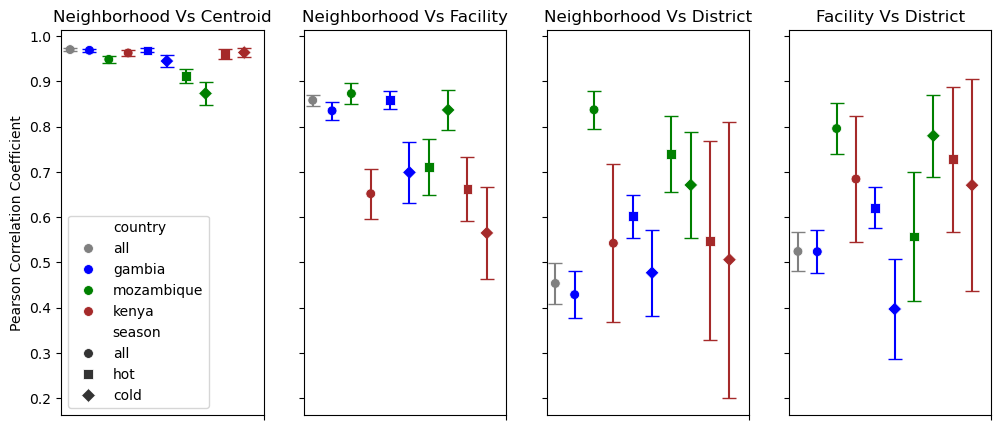

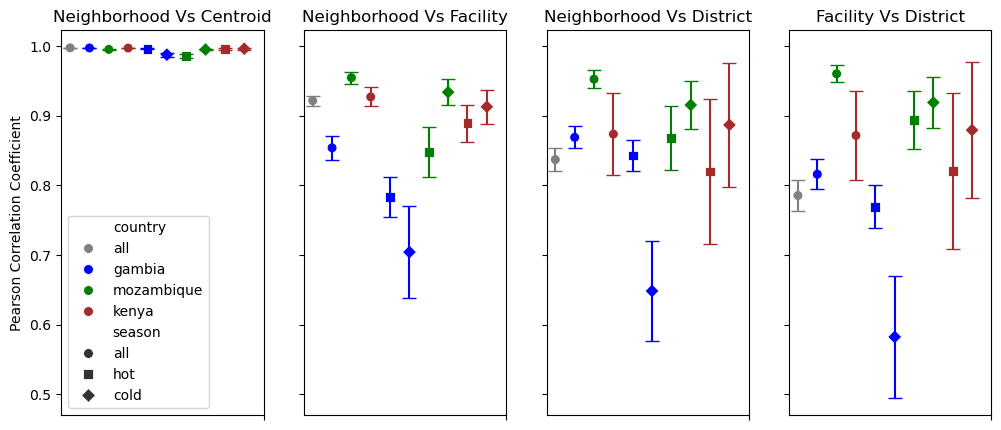

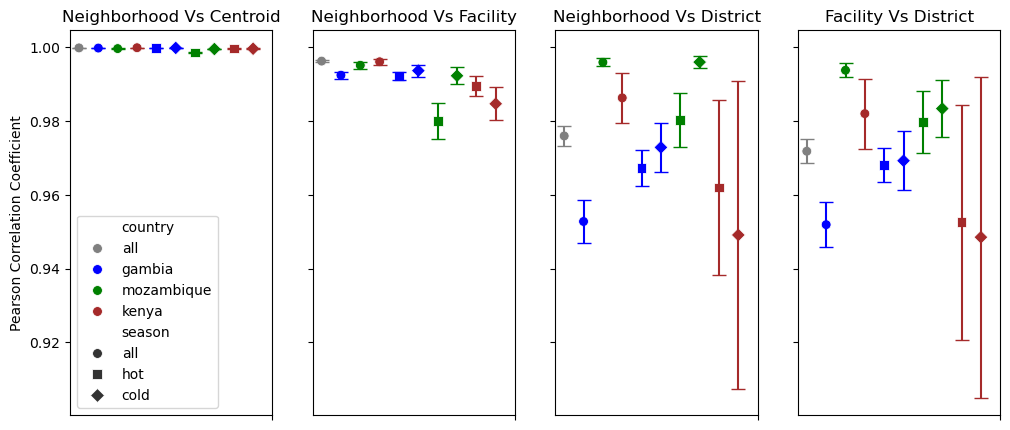

In [141]:
# source='era5'
for source in data_sources:
    
    # filter df to data source
    exposures=exposures_df[[source, 'neighborhood_code', 'exposure_month', 'assign_level', 'country', 'season']]
    dffs=compare_by_country_new(exposures, source)

    fig, axs=plt.subplots(1, 4, sharey=True, sharex=True, figsize=(12, 5))

    for idx, (df, title) in enumerate(zip(dffs.values(), ['Neighborhood Vs Centroid', 'Neighborhood Vs Facility', 'Neighborhood Vs District', 'Facility Vs District'])):

        # create subplots
        sns.scatterplot(df, x='level', y='coefficient', s=50, hue='country', style='season', palette=['grey', 'blue', 'green', 'brown'], markers=['o', 's', 'D'], ax=axs[idx])
        # subset data for errorbar color formatting
        for group, color in zip(df['country'].unique(), ['grey', 'blue', 'green', 'brown']):
            subset=df[df['country']==group]
            axs[idx].errorbar(subset['level'], subset['coefficient'], yerr=subset['upper']-subset['lower'], fmt='none', capsize=5, ecolor=color)

        axs[idx].set_title(title)

    for ax in axs.flatten():
        ax.set_xticks('')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.legend().set_visible(False)
    axs[0].set_ylabel('Pearson Correlation Coefficient')
    axs[0].legend(ncol=1).set_visible(True)

    # plt.savefig(os.path.join('outputs/figures_maps', f'{source}_correlation_plots.png'))

### Month-on-month comparison

In [ ]:
# df_vc=pd.DataFrame(columns=['level', 'coefficient', 'lower', 'upper']) # village_centroid
# df_vf=pd.DataFrame(columns=['level', 'coefficient', 'lower', 'upper']) # village_facility
# df_cf=pd.DataFrame(columns=['level', 'coefficient', 'lower', 'upper']) # centroid_facility
# count=0
# for country in countries:
#     exposures_filtered=pd.merge(exposures_df[exposures_df['assign_level']==a], exposures_df[exposures_df['assign_level']==b],\
#                                 on=['neighborhood_code', 'exposure_month', 'country', 'season'], validate='1:1', suffixes=[f'_{a}', f'_{b}'])
#     exposures_filtered=exposures_filtered[exposures_filtered['country']==country]
    
#     for month in exposures_filtered['month'].unique():
#         exposures=exposures_filtered[exposures_filtered['month']==month]        
#         # stratified by country
#         df_lm.loc[count, ['level', 'coefficient', 'lower', 'upper']]=compute(exposures, 'landsat', 'modis', f'{country} all villages')
#         df_lm.loc[count, 'month']=month
#         df_le.loc[count, ['level', 'coefficient', 'lower', 'upper']]=compute(exposures, 'landsat', 'era5', f'{country} all villages')
#         df_le.loc[count, 'month']=month
#         df_me.loc[count, ['level', 'coefficient', 'lower', 'upper']]=compute(exposures, 'modis', 'era5', f'{country} all villages')
#         df_me.loc[count, 'month']=month
#         count+=1

In [ ]:
# for df in [df_lm, df_le, df_me]:
#     df['country']=df['level'].map(lambda x: x.split(' ')[0])
#     df['season']=df.apply(assign_season, axis=1)
        
# fig, axs=plt.subplots(3, 1, sharey=True, sharex=True, figsize=(10, 12))

# for idx, (df, title) in enumerate(zip([df_lm, df_le, df_me], ['Landsat Vs Modis', 'Landsat Vs ERA-5', 'Modis Vs ERA-5'])):
#     # subset data for errorbar formatting
#     gm=df[df['country']=='gambia']
#     mz=df[df['country']=='mozambique']
#     # create subplots
#     sns.scatterplot(df, x='month', y='coefficient', s=50, hue='country', palette=['blue', 'green'], style='season', markers=['s', 'D'], ax=axs[idx])
#     # axs[idx].errorbar(gm['month'], gm['coefficient'], yerr=gm['upper']-gm['lower'], fmt='none', capsize=5, ecolor='blue')
#     # axs[idx].errorbar(mz['month'], mz['coefficient'], yerr=mz['upper']-mz['lower'], fmt='none', capsize=5, ecolor='green')
    
#     sns.lineplot(df, x='month', y='coefficient', hue='country', palette=['blue', 'green'], ax=axs[idx], legend=False)
#     axs[idx].set_title(title)

# for ax in axs.flatten():
#     # ax.set_xticks('')
#     ax.set_xlabel('')
#     ax.set_ylabel('')
#     ax.legend().set_visible(False)
# # axs[0].set_ylabel('Pearson Correlation Coefficient')
# axs[0].legend(ncol=2).set_visible(True)

# plt.savefig(os.path.join('outputs', 'monthly_correlation_plots.png'))

## Deciles comparison

We want to see if neighborhoods are classified into the same percentile (or decile) using exposures from different sources or different assignment levels.
Here's how we do it:
- calculate mean summer (hot months) and mean winter (cold months) temperature for each neighborhood stratified by (i) source and (ii) assignment level
- determine the neighborhood percentile/decile/quintile rank by same strata
- calculate percentile/decile/quintile differences by neighborhood
- plot boxplots of differences

In [60]:
def seasonal_mean_compute(seasonal=True):
    # step 1
    seasonal_means=pd.DataFrame()
    grp_cols=['neighborhood_code', 'country', 'assign_level']
    if seasonal:
        grp_cols.append('season')
    for code in exposures_df['neighborhood_code'].unique():
        exposures=(exposures_df[exposures_df['neighborhood_code']==code].groupby(by=grp_cols)[data_sources]
                   .mean()
                   .reset_index())
        seasonal_means=(pd.concat([seasonal_means, exposures])
                       .sort_values(by=['country', 'neighborhood_code']))
    
    return seasonal_means

### (i) By exposure source

In [61]:
def decile_diffs_bysource(assign_level):
    
    seasonal_mean_df=seasonal_mean_compute()

    # step 2a
    deciles_df=pd.DataFrame()
    for country in countries:
        for source in data_sources:
            for season in ['hot', 'cold']:
                means_=seasonal_mean_df.copy()
                means_=means_[(means_['country']==country) & (means_['season']==season) & (means_['assign_level']==assign_level)]
                means_[f'{source}_rank']=pd.cut(means_[source], 100, labels=False, duplicates='drop')+1

                deciles_df=pd.concat([deciles_df, means_])
    deciles_df=(deciles_df.groupby(by=['neighborhood_code', 'country', 'season'])[['landsat_rank', 'modis_rank', 'era5_rank']]
             .max()
             .reset_index())
    # step 3a
    for source in ['landsat_modis', 'landsat_era5', 'modis_era5']:
        a, b=source.split('_')
        deciles_df[source]=abs(deciles_df[f'{a}_rank']-deciles_df[f'{b}_rank'])
    
    return deciles_df

In [62]:
source_decile_dffs=dict()
for assign_level in assign_levels[:-1]: # omit district level difference which doesn't look good
    source_decile_dffs[assign_level]=decile_diffs_bysource(assign_level)

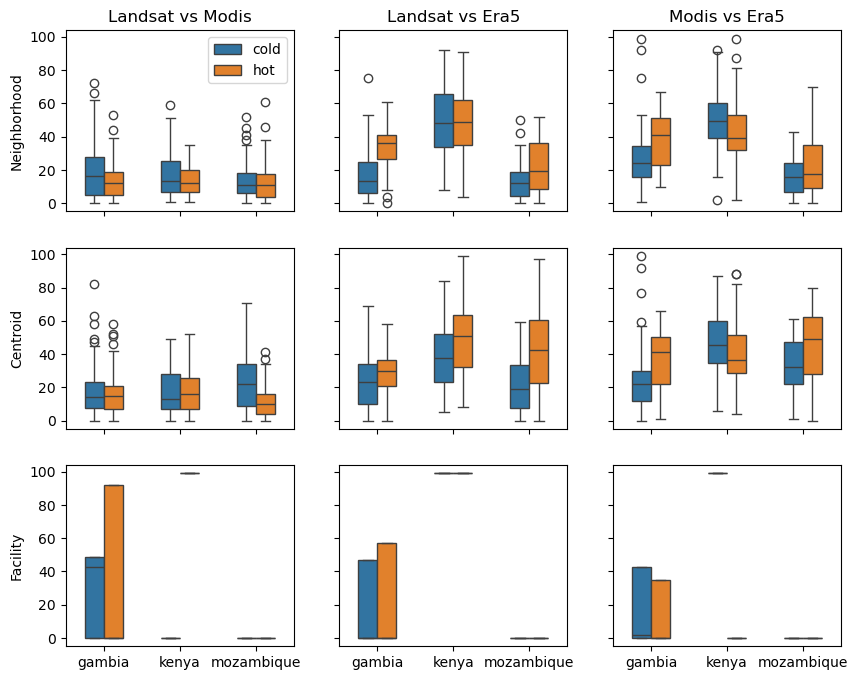

In [63]:
fig, axs=plt.subplots(3, 3, sharey=True, sharex=True, figsize=(10, 8))
for idx, assign_level in enumerate(source_decile_dffs.keys()):
    
    for idy, source in enumerate(['landsat_modis', 'landsat_era5', 'modis_era5']):
        sns.boxplot(source_decile_dffs[assign_level], x='country', y=source, hue='season', width=0.5, ax=axs[idx, idy])
        a, b=source.split('_')
        axs[0, idy].set_title(f'{a.capitalize()} vs {b.capitalize()}')
    axs[idx, 0].set_ylabel(assign_level.capitalize())

for ax in axs.flatten():
    ax.set_xlabel('')
    ax.legend().set_visible(False)
axs[0, 0].legend().set_visible(True)

### (ii) By assignment level

In [13]:
def decile_diffs_bylevel(source):
    
    seasonal_mean_df=seasonal_mean_compute()
    
    # step 2b
    deciles_df=pd.DataFrame()
    # make assign_levels to be columns
    seasonal_mean_df=(seasonal_mean_df.pivot(index=['neighborhood_code', 'country', 'season'], columns='assign_level', values=data_sources)
                      .stack(level=0)
                      .reset_index(names=['neighborhood_code', 'country', 'season', 'source']))
    
    for country in countries:
        for level in assign_levels:
            for season in ['hot', 'cold']:
                means_=seasonal_mean_df.copy()
                means_=means_[(means_['country']==country) & (means_['season']==season) & (means_['source']==source)]
                means_[f'{level}_rank']=pd.cut(means_[level], 100, labels=False, duplicates='drop')+1

                deciles_df=pd.concat([deciles_df, means_])
    deciles_df=(deciles_df.groupby(by=['neighborhood_code', 'country', 'season'])[['neighborhood_rank', 'centroid_rank', 'facility_rank', 'district_rank']]
             .max()
             .reset_index())
    # step 3b
    for level in ['neighborhood_centroid', 'neighborhood_facility', 'centroid_facility']:
        a, b=level.split('_')
        deciles_df[level]=abs(deciles_df[f'{a}_rank']-deciles_df[f'{b}_rank'])
    
    return deciles_df

In [14]:
level_decile_dffs=dict()
for source in data_sources:
    level_decile_dffs[source]=decile_diffs_bylevel(source)

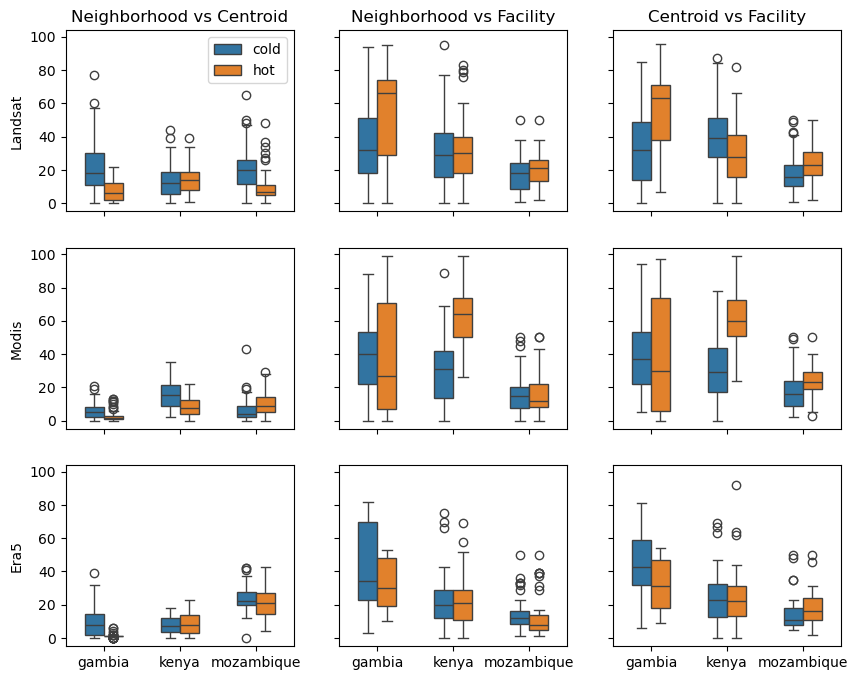

In [15]:
fig, axs=plt.subplots(3, 3, sharey=True, sharex=True, figsize=(10, 8))
for idx, source in enumerate(level_decile_dffs.keys()):
    
    for idy, level in enumerate(['neighborhood_centroid', 'neighborhood_facility', 'centroid_facility']):
        sns.boxplot(level_decile_dffs[source], x='country', y=level, hue='season', width=0.5, ax=axs[idx, idy])
        a, b=level.split('_')
        axs[0, idy].set_title(f'{a.capitalize()} vs {b.capitalize()}')
    axs[idx, 0].set_ylabel(source.capitalize())

for ax in axs.flatten():
    ax.set_xlabel('')
    ax.legend().set_visible(False)
axs[0, 0].legend().set_visible(True)

## Cross-tabulation

In [162]:
women_gm=(pd.read_csv(os.path.join('surveillance', 'Kenya', 'pregnancy_facility_location.csv'))
         .drop(columns=['conception_date', 'delivery_date']))
women_gm['country']='kenya'
# # enable sorting by ordered month names
# women_gm['month']=pd.Categorical(pd.to_datetime(women_gm['exposure_month'], format='%Y_%m').dt.strftime('%b'),
#                                  categories=map(lambda x: x.strftime('%b'), pd.date_range(1, periods=12, freq='M')), ordered=True)
# women_gm['season']=women_gm.apply(assign_season, axis=1)
women_gm

,Unnamed: 0,f2a_participant_id,exposure_month,village_code,facility_code,country
0,0,254-40004,2018_12,254062.0,Rabai,kenya
1,1,254-40004,2019_01,254062.0,Rabai,kenya
2,2,254-40004,2019_02,254062.0,Rabai,kenya
3,3,254-40004,2019_03,254062.0,Rabai,kenya
4,4,254-40004,2019_04,254062.0,Rabai,kenya
...,...,...,...,...,...,...
16476,16476,254-92532,2022_05,NaN,Mariakani,kenya
16477,16477,254-92532,2022_06,NaN,Mariakani,kenya
16478,16478,254-92532,2022_07,NaN,Mariakani,kenya
16479,16479,254-92532,2022_08,NaN,Mariakani,kenya


In [163]:
# women_gm=(women_gm.groupby(by=['f2a_participant_id', 'season'])[['village_code', 'facility_code', 'country']]
#           .agg({'village_code': np.median, 'facility_code': np.median, 'country': 'first',})
#           .reset_index())

women_gm=(women_gm.groupby(by='f2a_participant_id')[['village_code', 'country']]
          .agg({'village_code': np.median, 'country': 'first'})
          .reset_index())
women_gm

,f2a_participant_id,village_code,country
0,254-40004,254062.0,kenya
1,254-40020,254060.0,kenya
2,254-40085,254003.0,kenya
3,254-40127,254002.0,kenya
4,254-40134,254005.0,kenya
...,...,...,...
2003,254-92258,NaN,kenya
2004,254-92296,254051.0,kenya
2005,254-92346,NaN,kenya
2006,254-92494,254052.0,kenya


In [69]:
def decile_popn_bysource(assign_level):
    
    seasonal_mean_df=seasonal_mean_compute(False)

    # step 2a
    deciles_df=pd.DataFrame()
    for country in countries:
        for source in data_sources:
            means_=seasonal_mean_df.copy()
            means_=means_[(means_['country']==country) & (means_['assign_level']==assign_level)]
            means_[f'{source}_rank']=pd.cut(means_[source], 100, labels=False, duplicates='drop')+1

            deciles_df=pd.concat([deciles_df, means_])
    deciles_df=(deciles_df.groupby(by=['neighborhood_code', 'country'])[['landsat_rank', 'modis_rank', 'era5_rank']]
             .max()
             .reset_index())
    
    return deciles_df

In [70]:
source_decile_popn=dict()
for assign_level in assign_levels[:-1]: # omit district level difference which doesn't look good
    source_decile_popn[assign_level]=decile_popn_bysource(assign_level)

In [146]:
dff=source_decile_popn['facility']
dff=dff[dff['country']=='mozambique']
dataset_gm=pd.merge(women_gm, dff, left_on='village_code', right_on='neighborhood_code', validate='m:1')

In [149]:
# len(dataset_gm[(dataset_gm['season']=='cold')&((dataset_gm['modis_rank']>=95))])
len(dataset_gm[dataset_gm['era5_rank']>=95])/len(dataset_gm)

0.0

In [96]:
def decile_popn_bylevel(source):
    
    seasonal_mean_df=seasonal_mean_compute(False)
    
    # step 2b
    deciles_df=pd.DataFrame()
    # make assign_levels to be columns
    seasonal_mean_df=(seasonal_mean_df.pivot(index=['neighborhood_code', 'country'], columns='assign_level', values=data_sources)
                      .stack(level=0)
                      .reset_index(names=['neighborhood_code', 'country', 'source']))
    
    for country in countries:
        for level in assign_levels:
            means_=seasonal_mean_df.copy()
            means_=means_[(means_['country']==country) & (means_['source']==source)]
            means_[f'{level}_rank']=pd.cut(means_[level], 100, labels=False, duplicates='drop')+1

            deciles_df=pd.concat([deciles_df, means_])
    deciles_df=(deciles_df.groupby(by=['neighborhood_code', 'country'])[['neighborhood_rank', 'centroid_rank', 'facility_rank', 'district_rank']]
             .max()
             .reset_index())
    
    return deciles_df

In [97]:
level_decile_popn=dict()
for source in data_sources:
    level_decile_popn[source]=decile_popn_bylevel(source)

In [172]:
dff=level_decile_popn['era5']
dff=dff[dff['country']=='kenya']
dataset_gm=pd.merge(women_gm, dff, left_on='village_code', right_on='neighborhood_code', validate='m:1')

C:\Users\s1465450\AppData\Local\Temp\ipykernel_18200\549395397.py:3: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  dataset_gm=pd.merge(women_gm, dff, left_on='village_code', right_on='neighborhood_code', validate='m:1')


In [175]:
len(dataset_gm[dataset_gm['facility_rank']>=95])/len(dataset_gm)

0.5132877752467729

In [186]:
cohorts=pd.read_csv(os.path.join('outputs', 'exposed_cohorts.csv'))
cohorts

,source,women,country,assign_level
0,landsat,1.9,gambia,neighborhood
1,landsat,1.0,gambia,centroid
2,landsat,16.9,gambia,facility
3,modis,48.3,gambia,neighborhood
4,modis,6.1,gambia,centroid
5,modis,66.1,gambia,facility
6,era5,0.3,gambia,neighborhood
7,era5,0.3,gambia,centroid
8,era5,16.6,gambia,facility
9,landsat,0.7,mozambique,neighborhood


In [ ]:
cohorts[cohorts['source']==source]

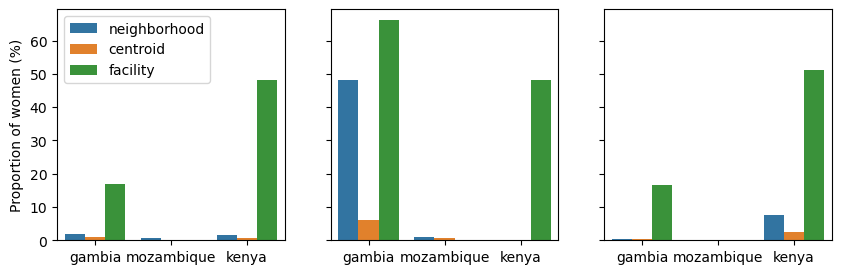

In [187]:
fig, axs=plt.subplots(1, 3, sharey=True, figsize=(10, 3))
for idx, source in enumerate(data_sources):
    sns.barplot(cohorts[cohorts['source']==source], x='country', y='women', hue='assign_level', ax=axs[idx])
axs[0].set_ylabel('Proportion of women (%)')
for ax in axs.flatten():
    ax.set_xlabel('')
    ax.legend().set_visible(False)
axs[0].legend().set_visible(True)

## Defining and calculating extreme heat exposure

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
from DataAnalyst_v4.heat import Heat

In [ ]:
# np.random.seed(10)
# dates=pd.date_range(start='2018-01-01', end='2023-12-31')
# villages=[f"258{str(i).zfill(3)}" for i in range(50)]
# sample_data=pd.DataFrame({
#     'date': np.tile(dates, 50),
#     'village': np.repeat(villages, len(dates)),
#     'temperature': np.random.normal(loc=25, scale=10, size=len(dates)*len(villages)) # Simulated daily mean temperatures
# })
# sample_data['village']=sample_data['village'].astype('int')
# sample_data

In [50]:
gambia_neighborhoods=Heat(os.path.join('outputs/daily_temperature/Gambia', 'modis_gambia_neighborhoods.csv'))
gambia_neighborhoods.getData()
# sample_data[(sample_data['village']==258009) & (sample_data['is_heatwave'])]

,exposure_date,lst,name,neighborhood_code
0,2018-11-01,35.518492,Alicali Kunda,3
92,2018-11-09,37.475147,Alicali Kunda,3
184,2018-11-17,36.748623,Alicali Kunda,3
276,2018-11-25,35.811620,Alicali Kunda,3
368,2018-12-03,37.348092,Alicali Kunda,3
...,...,...,...,...
17295,2022-11-25,36.290000,Wharftown,277
17387,2022-12-03,37.810000,Wharftown,277
17479,2022-12-11,37.250000,Wharftown,277
17571,2022-12-19,34.810000,Wharftown,277


In [52]:
df=gambia_neighborhoods.heatwave()
df[df['consecutive_hot_days']>=3].groupby(by=['name', 'block']).agg({'consecutive_hot_days': 'first'}) 

consecutive_hot_days
name              block                      
Bahen             10                        3
Balingho          10                        3
Balo Ibra         8                         3
Balo Omar         8                         3
Bassik            4                         3
                  8                         3
Beretto           8                         3
Burang Ya         2                         3
Chamaya           4                         3
Chamen            8                         3
Cheedi Laibe Ya   4                         3
DARU SALAM        2                         4
DIPA KUNDA        3                         3
Dafa              8                         3
Dipa Kunda Wollof 8                         3
Duto Koto         8                         3
Farafenni         8                         3
Fofana Kunda      10                        3
GUMALOYA          4                         3
Gallo Ya          4                         3
Jabbi Kunda       8                         3
Jally Kunda       10                        3
Jamagen           2                         3
                  4                         3
Jamal Mballo      8                         3
Jeriko            8                         3
Jigimar           8                         3
Jumansari         10                        3
Kani Kunda        4                         3
Ker Ali           10                        3
Kerr Madi         10                        3
Kerr Sulay        10                        3
Kunjung           8                         3
Lang Sarr         10                        3
MARRONG KUNDA     4                         3
Maka Farafenni    8                         3
Misira            4                         4
N'Geyen Sabach    8                         3
N'Geyen Sanjal    8                         3
N'Yang Kunda      6                         3
NYIRBAYA          4                         3
New Town          8                         3
Ngueur            8                         3
Njangen           8                         3
No Kunda          2                         3
Passi Mut         8                         3
Police Line       8                         3
Region            8                         3
Samba Sotor       8                         3
Sancha Madina     8                         3
Sanchaba          8                         3
Sankalang         8                         3
Sansangkono       8                         3
Sinchu Medina     8                         3
Sukoto Fula       8                         3
Walalan           10                        3
Wharftown         8                         3

In [53]:
gambia_women=pd.read_csv(os.path.join('outputs/anc_structured/Gambia', 'Gambia_daily_gestation_location.csv'))
gambia_women['exposure_date']=pd.to_datetime(gambia_women['exposure_date'], format='%d/%m/%Y')
gambia_women

,f2a_participant_id,exposure_date,neighborhood_code,facility_code
0,220-10005,2019-01-02,48,2201
1,220-10005,2019-01-03,48,2201
2,220-10005,2019-01-04,48,2201
3,220-10005,2019-01-05,48,2201
4,220-10005,2019-01-06,48,2201
...,...,...,...,...
279006,220-24838,2022-01-18,83,2202
279007,220-24838,2022-01-19,83,2202
279008,220-24838,2022-01-20,83,2202
279009,220-24838,2022-01-21,83,2202


In [56]:
analysis_df=pd.merge(gambia_women, df, on=['neighborhood_code', 'exposure_date'], how='left', validate='m:1')
analysis_df.drop(columns='facility_code')

,f2a_participant_id,exposure_date,neighborhood_code,lst,name,extreme_heat,is_hot_day,block,consecutive_hot_days,is_heatwave_day
0,220-10005,2019-01-02,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,220-10005,2019-01-03,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,220-10005,2019-01-04,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,220-10005,2019-01-05,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,220-10005,2019-01-06,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
279006,220-24838,2022-01-18,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
279007,220-24838,2022-01-19,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
279008,220-24838,2022-01-20,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
279009,220-24838,2022-01-21,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
